### *PhotoDissociation Region Toolbox Notebooks*
-------------------------------------------------------------

# Fitting $H_2$ Excitation on Spatial Maps

## Table of Contents
* [Introduction](#introduction)
* [Import Python modules](#import)
* [Reading Centaaurs A JWST Maps](#reading-test-maps)
* [Fitting a Rectangular Region](#rectangular-region-fit)
* [Fitting Every Pixel in the Map](#full-map-fit)
* [Exploring the Results](#exploring-results)

## Introduction <a id="introduction"></a>
This notebook shows how to fit $H_2$ excitation diagrams to spatial *maps* (images) of intensity, rather than single-pixel `Measurements`. It builds directly on the concepts (temperature components, ortho-to-para ratio, column density) introduced in [PDRT_Example_H2_Excitation.ipynb](PDRT_Example_H2_Excitation.ipynb), which is recommended background reading before working through this notebook. Here, `H2ExcitationFit` is applied either to an average over a rectangular region of the map, or pixel-by-pixel across the entire map, with results explored interactively and plotted spatially.

The first step is to import the modules we will need. <a id="import"></a>

In [1]:
from pdrtpy.measurement import Measurement
from pdrtpy.tool.h2excitation import H2ExcitationFit
from pdrtpy.plot.excitationplot import ExcitationPlot
from pdrtpy.utils.paths import get_testdata
from astropy.nddata import StdDevUncertainty
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

------------------------------------------------------------
## Read in Centaurus A JWST maps <a id="reading-test-maps"></a>
------------------------------------------------------------

The data are $H_2$ intensity images (Lorenzo+ 2025) which have been converted to ``Measurements`` using ``Measurement.make_measurement`` with a 10% error.

In [2]:
maps = {}
for j in range(1,9):
    key = f'H200S{j}'
    file = get_testdata(f'{key}_CenA.fits')
    maps[key] = Measurement.read(file,identifier=key)
print(f"Got Measurements for {list(maps.keys())}")

Got Measurements for ['H200S1', 'H200S2', 'H200S3', 'H200S4', 'H200S5', 'H200S6', 'H200S7', 'H200S8']


### Plot the maps

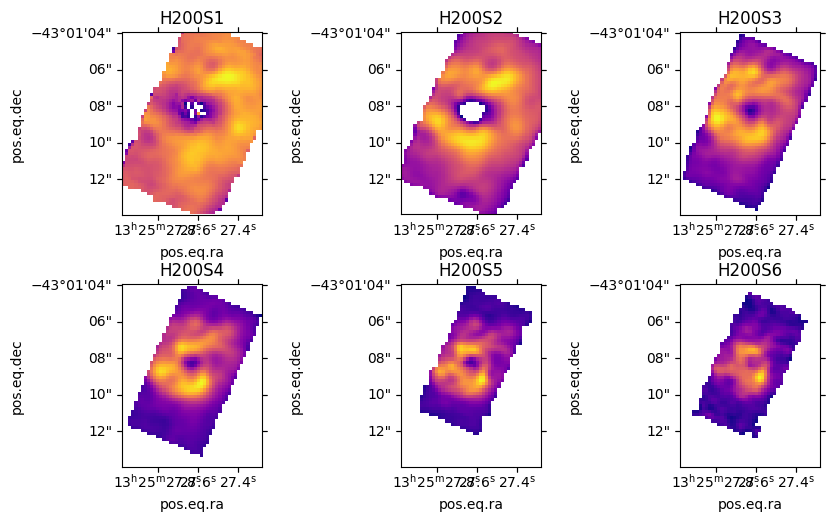

In [3]:
wcskey='H200S1'

fig,ax = plt.subplots(2,3,figsize=(9,6),subplot_kw={'projection':maps[wcskey].wcs})
m = iter(maps.values())
for a in ax:
    for b in a:
        q = next(m)
        b.imshow(q,origin="lower",norm='asinh',cmap='plasma')
        b.set_title(q.id)

plt.subplots_adjust(wspace=1)

### Fit to a rectangular spatial area in the image data over which the column densities are averaged

#### Here we select a rectangle centered on the blob, compute the average column densities,and plot the rectangle on the H200S1 map.
The area center `position` and `size` are in pixels. [`Astropy's Cutout2D`](https://docs.astropy.org/en/stable/api/astropy.nddata.utils.Cutout2D.html#astropy.nddata.utils.Cutout2D) is used underneath the hood. The statistical errors in the column densities are computed from the rms noise of the map which was specified in the FITS file. In this example, the subsequent error bars are smaller than the plot symbols.

N_u(H200S1)/g_u = 2.65e+18 +/- 4.46e+15 1 / cm2
N_u(H200S2)/g_u = 4.27e+17 +/- 7.16e+14 1 / cm2
N_u(H200S3)/g_u = 3.60e+16 +/- 7.09e+13 1 / cm2
N_u(H200S4)/g_u = 1.58e+16 +/- 3.18e+13 1 / cm2
N_u(H200S5)/g_u = 4.21e+15 +/- 9.53e+12 1 / cm2
N_u(H200S6)/g_u = 9.86e+14 +/- 2.44e+12 1 / cm2
N_u(H200S7)/g_u = 3.60e+14 +/- 9.75e+11 1 / cm2
N_u(H200S8)/g_u = 1.01e+14 +/- 2.68e+11 1 / cm2


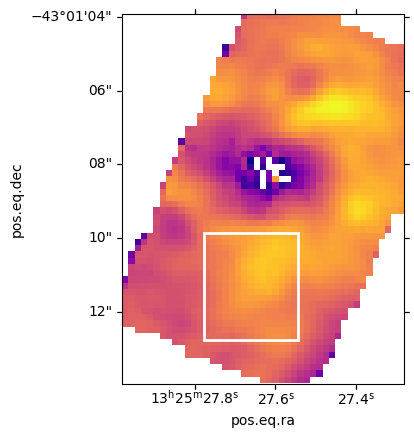

In [4]:
# Center of the box
x = 20
y = 15
# Size of the box
size=(15.0,17.0)
hmap = H2ExcitationFit(list(maps.values()))
cd=hmap.average_column_density(norm=True,position=(x,y),size=size,line=True)
for k in cd:
    print(r"N_u({:s})/g_u = {:5.2e}".format(k,cd[k]))
    
# Show the rectangle on one of the maps
x0 = x-size[0]/2
y0 = y-size[1]/2
fig = plt.figure()
ax = plt.subplot(111,projection=maps[wcskey].wcs)
ax.add_patch(Rectangle((x0,y0),size[0],size[1],facecolor='None',ec='white',lw=2))
ax.imshow(maps[wcskey],origin="lower",norm='asinh',cmap='plasma')
plt.show()

### Once we are satisfied with the choice, we pass the same rectangle to `run()`.

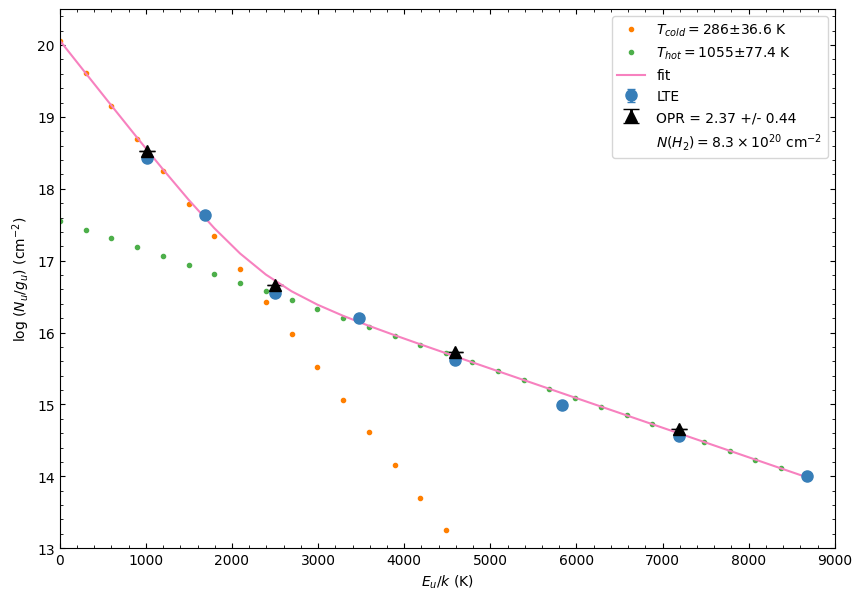

In [5]:
hmap.run(position=(x,y),size=size,fit_opr=True)
hplot = ExcitationPlot(hmap,"H_2")
hplot.ex_diagram(position=(x,y),size=size,norm=True,show_fit=True,ymax=20.5,xmin=0,xmax=9000)

### The individual fitted parameters from the ExcitationFit

In [6]:
# use various format styles to show how Measurements obey Python formatting
print(f'T(cold) = {hmap.tcold}')
print("T(hot) = {:>8.3f}".format(hmap.thot))
print(f'N(cold) = {hmap.cold_colden:3.2E}')
print(f'N(hot) = {hmap.hot_colden:3.2E}')
print(f'N(total) = {hmap.total_colden:+.1e}')
print(f"Ortho-to-para ratio = {hmap.opr:.2f}")

T(cold) = 285.9582031573241 +/- 36.612777184540896 K
T(hot) = 1055.392 +/-   77.373 K
N(cold) = 8.18E+20 +/- 5.25E+20 1 / cm2
N(hot) = 9.43E+18 +/- 4.16E+18 1 / cm2
N(total) = +8.3e+20 +/- +5.2e+20 1 / cm2
Ortho-to-para ratio = 2.37 +/- 0.44 


------------------------------------------------------------
## Fitting every pixel in the map <a id="full-map-fit"></a>
------------------------------------------------------------

### Run the fit on every pixel in the map
This is done by  setting `position` and `size` to None (which is also the default). This may take several seconds depending on your CPU resources.


In [18]:
hmap.run(position=None,size=None,fit_opr=True, components=2,nan_policy='propagate')

/bigdisk/src/pclaude/pdrtpy/pdrtpy/tool/excitation.py:1303: RuntimeWarning: Mean of empty slice
  intcold[i] = float(np.nanmean(y_1d))
/bigdisk/src/pclaude/pdrtpy/pdrtpy/tool/excitation.py:1305: RuntimeWarning: Mean of empty slice
  inthot[i] = float(np.nanmean(y_1d))
100%|██████████████████████████████████████| 2655/2655 [00:05<00:00, 517.92it/s]


------------------------------------------------------------
## Exploring the results <a id="exploring-results"></a>
------------------------------------------------------------

### You can examine the results with the `explore` method
explore() plots data on the left panel and the fit at the selected pixel on the right panel.  Click on anywhere in the left panel to see the fit for that pixel.   This example uses the total column density for the left panel.

#### In order for the `explore()` method to work in a noteboook, you have to invoke this directive mpl-interactions package required).



In [8]:
%matplotlib ipympl

### Let's first look at $T_{cold}$

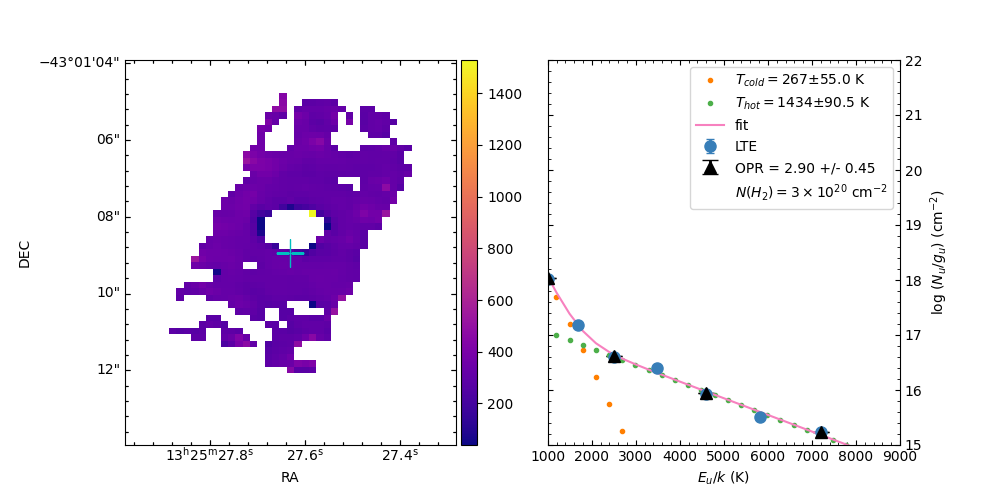

In [20]:
hplot.explore(data=hmap.tcold,figsize=(10,5),log=False,contours=False,fmt='c+')

In [25]:
hplot.explore(data=hmap.colden("total"),vmin=20,vmax=23,figsize=(10,5),log=True,contours=False,fmt='c+')

### And here is `explore` with $T_{hot}$

In [23]:
hplot.explore(data=hmap.thot,vmin=500,vmax=1000,figsize=(10,5),log=False,contours=False,fmt='c+')

### Finally, here are some plots of total column density and ortho-to-para ratio
`component` can be 'total', 'hot', or 'cold'

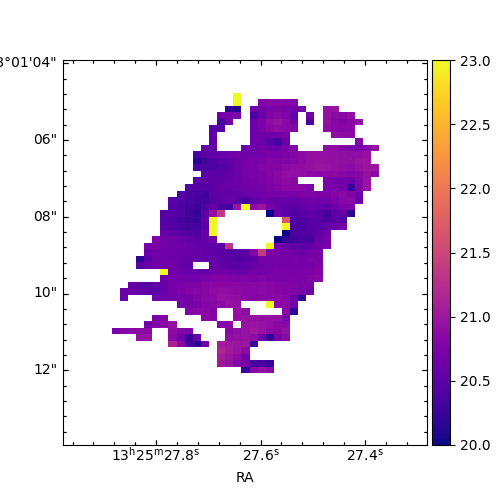

In [24]:
hplot.column_density(component='total',log=True,norm='simple',contours=False,vmin=20,vmax=23)

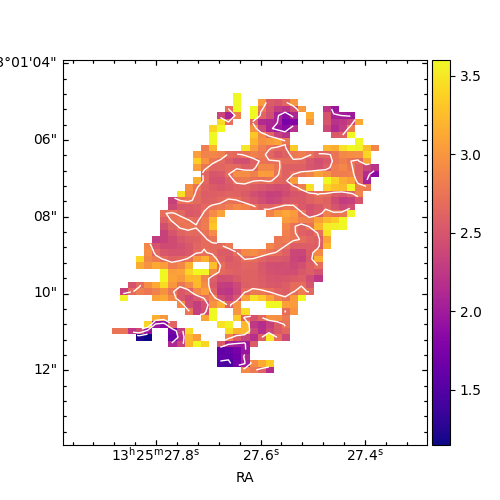

In [26]:
hplot.opr()

### Look at some aggregate values

In [27]:
# N(J=0) Hot column density = intercept on y axis of T_hot
c0 = hmap._j0_colden['hot']
# N(J=0) Cold  column density = intercept on y axis T_cold
c1 = hmap._j0_colden['cold']
# Total cold column density
c2 = hmap.colden('cold')
# Total hot column density
c3 = hmap.colden('total')
print(f'Mean values: {np.nanmean(c0):.2e}, {np.nanmean(c1):.2e}, {np.nanmean(c2):.2e}, {np.nanmean(c3):.2e}')
print(f' Max values: {np.nanmax(c0):.2e}, {np.nanmax(c1):.2e}, {np.nanmax(c2):.2e}, {np.nanmax(c3):.2e}')

Mean values: 5.10e+17, 4.80e+26, 4.79e+26, 4.81e+26
 Max values: 4.33e+18, 9.80e+28, 9.91e+28, 9.91e+28
